In [12]:
# ============================================================
# FIXED CELL 1 — Install Dependencies (no TF version pin)
# ============================================================
# Colab already has TensorFlow installed. Just install the extras.
!pip install scikit-learn matplotlib pandas tqdm gdown

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("All dependencies installed.")


TensorFlow version: 2.20.0
All dependencies installed.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import math
import json
import time
import random
import warnings
from collections import defaultdict
from tqdm import tqdm

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Python version:", sys.version)


TensorFlow version: 2.20.0
NumPy version: 2.1.3
Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [14]:
SEED = 0
np.random.seed(SEED)
random.seed(SEED)
tf.set_random_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print("Random seeds set to", SEED)


Random seeds set to 0


In [15]:
import subprocess

print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

gpu_available = tf.test.is_gpu_available()
print("GPU Available:", gpu_available)

if gpu_available:
    gpu_name = tf.test.gpu_device_name()
    print("GPU Device:", gpu_name)
    try:
        result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                                  '--format=csv,noheader'], capture_output=True, text=True)
        print("GPU Details:", result.stdout.strip())
    except:
        pass
else:
    print("No GPU detected. The model is small (271K params), CPU is fine.")

print("TensorFlow version:", tf.__version__)
print("Python version:", sys.version.split()[0])
print("CUDA built with TF:", tf.test.is_built_with_cuda())


DEVICE INFORMATION
GPU Available: True
GPU Device: /device:GPU:0
GPU Details: Tesla T4, 15360 MiB
TensorFlow version: 2.20.0
Python version: 3.13.15
CUDA built with TF: True


In [16]:
# === EXPERIMENT MODE ===
FULL_EXPERIMENT = True   # False for quick 10-round run

# === Dataset ===
DATASET_NAME = "imu_data_7"

# === FL Setup (from client_cfmtl.py & server_cfmtl.py) ===
NUM_OF_TOTAL_USERS = 7
NUM_OF_CLASS = 3
DIMENSION_OF_FEATURE = 900
_BATCH_SIZE = 5

# === Training samples (from client_cfmtl.py L29-32) ===
LOW_SCALE = 10
HIGH_SCALE = 50
np.random.seed(SEED)
train_N_set = np.random.randint(low=LOW_SCALE, high=HIGH_SCALE, size=NUM_OF_TOTAL_USERS)
NUM_TEST_EXAMPLES_PER_USER = 50

# === Hyperparameters (from client_cfmtl.py & server_cfmtl.py) ===
alpha = 1e-3
beta = 5e-4
rho = 2e-3
initial_learning_rate = 1e-2
step_rate = 100
decay = 0.999

# === Communication (from server_cfmtl.py) ===
inner_iteration = 3
T_thresh = 10
softmax_temperature = 6.0
convergence_threshold = 1e-2

# === Rounds and epochs ===
if FULL_EXPERIMENT:
    local_iter = 20
    outer_iter = 50
else:
    local_iter = 10
    outer_iter = 10

# === Model ===
W_DIM = 271203

# === Paths ===
BASE_DIR = "/content"
REPO_DIR = os.path.join(BASE_DIR, "ClusterFL")
DATA_DIR = os.path.join(BASE_DIR, "dataset", DATASET_NAME)
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# === Cluster structure (from data_pre.py) ===
cluster_set = ['hsh_', 'mmw_']
class_set = ['_walk', '_up', '_down']

print("=" * 60)
print("CLUSTERFL EXPERIMENT CONFIGURATION")
print("=" * 60)
print(f"  Mode:                {'FULL PAPER EXPERIMENT' if FULL_EXPERIMENT else 'COLAB-FRIENDLY REDUCED'}")
print(f"  Dataset:             {DATASET_NAME}")
print(f"  Number of clients:   {NUM_OF_TOTAL_USERS}")
print(f"  Number of clusters:  2 (ground truth)")
print(f"  Number of classes:   {NUM_OF_CLASS}")
print(f"  Feature dimension:   {DIMENSION_OF_FEATURE}")
print(f"  Communication rounds:{outer_iter}")
print(f"  Local epochs:        {local_iter}")
print(f"  Batch size:          {_BATCH_SIZE}")
print(f"  Learning rate:       {initial_learning_rate}")
print(f"  LR decay:            {decay} every {step_rate} steps")
print(f"  Optimizer:           SGD")
print(f"  alpha:               {alpha}")
print(f"  beta:                {beta}")
print(f"  rho:                 {rho}")
print(f"  F update frequency:  Every {inner_iteration} rounds")
print(f"  Softmax temperature: {softmax_temperature}")
print(f"  Model:               2-layer FC (900->300->3)")
print(f"  W_DIM (total params):{W_DIM:,}")
print(f"  Random seed:         {SEED}")
print(f"  Device:              {'GPU' if tf.test.is_gpu_available() else 'CPU'}")
print(f"  Train samples/user:  {train_N_set.tolist()}")
print(f"  Test samples/user:   {NUM_TEST_EXAMPLES_PER_USER}")
print("=" * 60)


CLUSTERFL EXPERIMENT CONFIGURATION
  Mode:                FULL PAPER EXPERIMENT
  Dataset:             imu_data_7
  Number of clients:   7
  Number of clusters:  2 (ground truth)
  Number of classes:   3
  Feature dimension:   900
  Communication rounds:50
  Local epochs:        20
  Batch size:          5
  Learning rate:       0.01
  LR decay:            0.999 every 100 steps
  Optimizer:           SGD
  alpha:               0.001
  beta:                0.0005
  rho:                 0.002
  F update frequency:  Every 3 rounds
  Softmax temperature: 6.0
  Model:               2-layer FC (900->300->3)
  W_DIM (total params):271,203
  Random seed:         0
  Device:              GPU
  Train samples/user:  [10, 13, 13, 49, 19, 29, 31]
  Test samples/user:   50


In [20]:
# ============================================================
# EXTRACT imu_dataset.zip into imu_data_7
# ============================================================
import zipfile

zip_path = "/content/dataset/imu_dataset.zip"
extract_to = "/content/dataset"

print("Extracting imu_dataset.zip...")
with zipfile.ZipFile(zip_path, 'r') as z:
    print(f"  Contents: {z.namelist()[:10]}...")  # peek at structure
    z.extractall(extract_to)

# Find where the _nor.txt files ended up
import subprocess
result = subprocess.run(['find', '/content/dataset', '-name', '*_nor.txt', '-type', 'f'],
                       capture_output=True, text=True, timeout=30)

if result.stdout.strip():
    files = result.stdout.strip().split('\n')
    src_dir = os.path.dirname(files[0])
    print(f"\n  Found {len(files)} files in: {src_dir}")

    # Move to DATA_DIR if needed
    if src_dir != DATA_DIR:
        print(f"  Copying to: {DATA_DIR}")
        os.makedirs(DATA_DIR, exist_ok=True)
        for f in files:
            fname = os.path.basename(f)
            dest = os.path.join(DATA_DIR, fname)
            if not os.path.exists(dest):
                import shutil
                shutil.copy2(f, dest)

    count = len([f for f in os.listdir(DATA_DIR) if f.endswith('_nor.txt')])
    print(f"\n✅ {count} data files ready in {DATA_DIR}")
    !ls {DATA_DIR}/*_nor.txt | head -25
else:
    print("❌ No _nor.txt files found after extraction.")
    print("Listing extracted contents:")
    !find /content/dataset -maxdepth 3 -type f | head -30


Extracting imu_dataset.zip...
  Contents: ['imu_dataset/', 'imu_dataset/hsh_1_walk_nor.txt', '__MACOSX/imu_dataset/._hsh_1_walk_nor.txt', 'imu_dataset/hsh_2_down_nor.txt', '__MACOSX/imu_dataset/._hsh_2_down_nor.txt', 'imu_dataset/.DS_Store', '__MACOSX/imu_dataset/._.DS_Store', 'imu_dataset/hsh_3_up_nor.txt', '__MACOSX/imu_dataset/._hsh_3_up_nor.txt', 'imu_dataset/hsh_3_down_nor.txt']...

  Found 42 files in: /content/dataset/imu_dataset
  Copying to: /content/dataset/imu_data_7

✅ 42 data files ready in /content/dataset/imu_data_7
/content/dataset/imu_data_7/hsh_1_down_nor.txt
/content/dataset/imu_data_7/hsh_1_up_nor.txt
/content/dataset/imu_data_7/hsh_1_walk_nor.txt
/content/dataset/imu_data_7/hsh_2_down_nor.txt
/content/dataset/imu_data_7/hsh_2_up_nor.txt
/content/dataset/imu_data_7/hsh_2_walk_nor.txt
/content/dataset/imu_data_7/hsh_3_down_nor.txt
/content/dataset/imu_data_7/hsh_3_up_nor.txt
/content/dataset/imu_data_7/hsh_3_walk_nor.txt
/content/dataset/imu_data_7/hsh_4_down_nor.txt

In [21]:
# ============================================================
# FIXED CELL 6 — Clone Repository & Download Dataset (ROBUST)
# ============================================================
import glob, zipfile

# 1. Clone repo
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/xmouyang/ClusterFL.git {REPO_DIR}
    print("Repository cloned.")
else:
    print("Repository already exists.")

# 2. Download dataset — try multiple methods
DATASET_BASE = os.path.join(BASE_DIR, "dataset")
os.makedirs(DATASET_BASE, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Check if data already exists
test_file = os.path.join(DATA_DIR, "hsh_1_walk_nor.txt")
if os.path.exists(test_file):
    print("Dataset already exists at:", DATA_DIR)
else:
    print("Downloading imu_data_7 dataset...")

    # --- METHOD 1: Clone FL-Datasets-for-HAR repo (has data_pre.py + links) ---
    FL_REPO = "/content/FL-Datasets-for-HAR"
    if not os.path.exists(FL_REPO):
        !git clone https://github.com/xmouyang/FL-Datasets-for-HAR.git {FL_REPO}

    # --- METHOD 2: Try direct Dropbox download of the IMU dataset zip ---
    # These are known Dropbox share links for FL-Datasets-for-HAR
    dropbox_urls = [
        "https://www.dropbox.com/sh/bjgfb91052nmpz6/AAD7v_HAmJwPvPmCTQnCmISma?dl=1",
    ]

    downloaded = False
    for url in dropbox_urls:
        print(f"  Trying: {url[:60]}...")
        try:
            !wget -q --show-progress -O /content/dataset/fl_data.zip "{url}" 2>&1 | tail -1
            if os.path.exists("/content/dataset/fl_data.zip") and \
               os.path.getsize("/content/dataset/fl_data.zip") > 10000:
                print("  Download succeeded. Extracting...")
                !cd /content/dataset && unzip -q -o fl_data.zip
                downloaded = True
                break
            else:
                print("  Download too small or failed, trying next...")
        except:
            continue

    # Search for the actual data files anywhere under /content
    print("\nSearching for imu_data_7 files...")
    found_files = []
    for root, dirs, files in os.walk("/content"):
        for f in files:
            if f == "hsh_1_walk_nor.txt":
                found_files.append(root)

    if found_files:
        src_dir = found_files[0]
        print(f"  Found data at: {src_dir}")
        if src_dir != DATA_DIR:
            print(f"  Copying to: {DATA_DIR}")
            !cp "{src_dir}"/*_nor.txt "{DATA_DIR}/"
    else:
        print("\n" + "="*60)
        print("AUTOMATIC DOWNLOAD DID NOT FIND THE DATA FILES.")
        print("="*60)
        print("""
MANUAL UPLOAD REQUIRED — follow these steps:

1. Go to: https://www.dropbox.com/sh/bjgfb91052nmpz6/AAD7v_HAmJwPvPmCTQnCmISma?dl=0
2. Find and download the 'imu_data_7' folder/zip
3. Extract it — you need these 21 .txt files:
     hsh_1_walk_nor.txt, hsh_1_up_nor.txt, hsh_1_down_nor.txt
     hsh_2_walk_nor.txt, hsh_2_up_nor.txt, hsh_2_down_nor.txt
     hsh_3_walk_nor.txt, hsh_3_up_nor.txt, hsh_3_down_nor.txt
     hsh_4_walk_nor.txt, hsh_4_up_nor.txt, hsh_4_down_nor.txt
     mmw_1_walk_nor.txt, mmw_1_up_nor.txt, mmw_1_down_nor.txt
     mmw_2_walk_nor.txt, mmw_2_up_nor.txt, mmw_2_down_nor.txt
     mmw_3_walk_nor.txt, mmw_3_up_nor.txt, mmw_3_down_nor.txt
4. Then run the MANUAL UPLOAD cell below.
""")

# Final check
test_file = os.path.join(DATA_DIR, "hsh_1_walk_nor.txt")
if os.path.exists(test_file):
    count = len([f for f in os.listdir(DATA_DIR) if f.endswith('_nor.txt')])
    print(f"\n✅ Dataset ready: {count} files in {DATA_DIR}")
else:
    print(f"\n❌ Dataset NOT found at {DATA_DIR}")
    print("   Run the MANUAL UPLOAD cell below.")


Repository already exists.
Dataset already exists at: /content/dataset/imu_data_7

✅ Dataset ready: 42 files in /content/dataset/imu_data_7


In [22]:
print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

expected_files = []
for user_id in range(NUM_OF_TOTAL_USERS):
    if user_id < 4:
        cluster_id = 0
        intra_user_id = user_id + 1
    else:
        cluster_id = 1
        intra_user_id = user_id - 3
    cluster_des = cluster_set[cluster_id]
    for class_id in range(NUM_OF_CLASS):
        fname = f"{cluster_des}{intra_user_id}{class_set[class_id]}_nor.txt"
        expected_files.append(fname)

all_found = True
for fname in expected_files:
    fpath = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(fpath)
    status = "OK" if exists else "MISSING"
    if not exists:
        all_found = False
    print(f"  [{status}]  {fname}")

if all_found:
    print(f"\nAll {len(expected_files)} dataset files found!")
else:
    print(f"\nSome files are missing. Check DATA_DIR: {DATA_DIR}")

server_x_path = os.path.join(REPO_DIR, "server", "server_x_test.txt")
server_y_path = os.path.join(REPO_DIR, "server", "server_y_test.txt")
print(f"\n  server_x_test.txt: {'OK' if os.path.exists(server_x_path) else 'MISSING'}")
print(f"  server_y_test.txt: {'OK' if os.path.exists(server_y_path) else 'MISSING'}")


DATASET VERIFICATION
  [OK]  hsh_1_walk_nor.txt
  [OK]  hsh_1_up_nor.txt
  [OK]  hsh_1_down_nor.txt
  [OK]  hsh_2_walk_nor.txt
  [OK]  hsh_2_up_nor.txt
  [OK]  hsh_2_down_nor.txt
  [OK]  hsh_3_walk_nor.txt
  [OK]  hsh_3_up_nor.txt
  [OK]  hsh_3_down_nor.txt
  [OK]  hsh_4_walk_nor.txt
  [OK]  hsh_4_up_nor.txt
  [OK]  hsh_4_down_nor.txt
  [OK]  mmw_1_walk_nor.txt
  [OK]  mmw_1_up_nor.txt
  [OK]  mmw_1_down_nor.txt
  [OK]  mmw_2_walk_nor.txt
  [OK]  mmw_2_up_nor.txt
  [OK]  mmw_2_down_nor.txt
  [OK]  mmw_3_walk_nor.txt
  [OK]  mmw_3_up_nor.txt
  [OK]  mmw_3_down_nor.txt

All 21 dataset files found!

  server_x_test.txt: OK
  server_y_test.txt: OK


In [23]:
print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)

total_samples = 0
user_info = []

for user_id in range(NUM_OF_TOTAL_USERS):
    if user_id < 4:
        cluster_id = 0
        intra_user_id = user_id + 1
    else:
        cluster_id = 1
        intra_user_id = user_id - 3
    cluster_des = cluster_set[cluster_id]
    user_samples = 0
    class_counts = []
    for class_id in range(NUM_OF_CLASS):
        fname = f"{cluster_des}{intra_user_id}{class_set[class_id]}_nor.txt"
        fpath = os.path.join(DATA_DIR, fname)
        if os.path.exists(fpath):
            data = np.loadtxt(fpath, delimiter=',')
            samples = data.reshape(-1, DIMENSION_OF_FEATURE)
            n = samples.shape[0]
            class_counts.append(n)
            user_samples += n
        else:
            class_counts.append(0)
    total_samples += user_samples
    user_info.append({
        'user_id': user_id,
        'cluster': f"Cluster {cluster_id} ({cluster_des.strip('_')})",
        'total_samples': user_samples,
        'walk': class_counts[0],
        'up': class_counts[1],
        'down': class_counts[2],
        'train_alloc': int(train_N_set[user_id]),
    })

df_info = pd.DataFrame(user_info)
print(df_info.to_string(index=False))
print(f"\nTotal samples: {total_samples}")
print(f"Feature dim: {DIMENSION_OF_FEATURE}, Classes: {NUM_OF_CLASS}")
print(f"Clusters: 0=hsh (users 0-3), 1=mmw (users 4-6)")

server_x = np.loadtxt(os.path.join(REPO_DIR, "server", "server_x_test.txt"))
server_y = np.loadtxt(os.path.join(REPO_DIR, "server", "server_y_test.txt"))
print(f"\nServer test data: {server_x.shape[0]} samples x {server_x.shape[1]} features")
print(f"Server test labels: {dict(zip(*np.unique(server_y, return_counts=True)))}")


DATASET INSPECTION
 user_id         cluster  total_samples  walk  up  down  train_alloc
       0 Cluster 0 (hsh)            195    64  66    65           10
       1 Cluster 0 (hsh)            192    64  64    64           13
       2 Cluster 0 (hsh)            194    64  66    64           13
       3 Cluster 0 (hsh)            209    74  70    65           49
       4 Cluster 1 (mmw)            194    64  65    65           19
       5 Cluster 1 (mmw)            191    67  64    60           29
       6 Cluster 1 (mmw)            194    69  62    63           31

Total samples: 1369
Feature dim: 900, Classes: 3
Clusters: 0=hsh (users 0-3), 1=mmw (users 4-6)

Server test data: 70 samples x 900 features
Server test labels: {np.float64(0.0): np.int64(23), np.float64(1.0): np.int64(22), np.float64(2.0): np.int64(25)}


In [24]:
def load_data(user_id, data_dir):
    if user_id < 4:
        cluster_id = 0
        intra_user_id = user_id + 1
    else:
        cluster_id = 1
        intra_user_id = user_id - 3
    cluster_des = cluster_set[cluster_id]
    coll_class = []
    coll_label = []
    for class_id in range(NUM_OF_CLASS):
        read_path = os.path.join(
            data_dir,
            f"{cluster_des}{intra_user_id}{class_set[class_id]}_nor.txt"
        )
        temp_original_data = np.loadtxt(read_path, delimiter=',')
        temp_coll = temp_original_data.reshape(-1, DIMENSION_OF_FEATURE)
        count_img = temp_coll.shape[0]
        temp_label = class_id * np.ones(count_img)
        coll_class.extend(temp_coll)
        coll_label.extend(temp_label)
    return np.array(coll_class), np.array(coll_label), DIMENSION_OF_FEATURE


def generate_data(num_of_train_per_node, num_of_test_per_node, x_coll, y_coll):
    test_percent = 0.4
    x_train, x_test, y_train, y_test = train_test_split(
        x_coll, y_coll, test_size=test_percent, random_state=0)
    num_of_all_train_data = y_train.shape[0]
    num_of_all_test_data = y_test.shape[0]
    train_index = random.sample(range(0, num_of_all_train_data), num_of_train_per_node)
    test_index = random.sample(range(0, num_of_all_test_data), num_of_test_per_node)
    node_x_train = np.zeros((num_of_train_per_node, DIMENSION_OF_FEATURE))
    node_y_train = np.zeros(num_of_train_per_node)
    node_x_test = np.zeros((num_of_test_per_node, DIMENSION_OF_FEATURE))
    node_y_test = np.zeros(num_of_test_per_node)
    for i in range(num_of_train_per_node):
        node_x_train[i, :] = np.array(x_train[train_index[i]]).flatten().astype('float32')
        node_y_train[i] = y_train[train_index[i]]
    for i in range(num_of_test_per_node):
        node_x_test[i, :] = np.array(x_test[test_index[i]]).flatten().astype('float32')
        node_y_test[i] = y_test[test_index[i]]
    return node_x_train, node_x_test, node_y_train, node_y_test


def count_analysis(y):
    count_class = np.zeros(NUM_OF_CLASS)
    for class_id in range(NUM_OF_CLASS):
        count_class[class_id] = np.sum(y == class_id)
    return count_class


def to_categorical(y, num_classes):
    return np.eye(num_classes)[y.astype(int)]


print("Data loading functions defined.")


Data loading functions defined.


In [25]:
np.random.seed(SEED)
random.seed(SEED)
train_N_set = np.random.randint(low=LOW_SCALE, high=HIGH_SCALE, size=NUM_OF_TOTAL_USERS)

print("Loading data for all clients...")
print("Train samples per user:", train_N_set.tolist())

all_x_train = {}
all_y_train = {}
all_x_test = {}
all_y_test = {}

for user_id in range(NUM_OF_TOTAL_USERS):
    random.seed(SEED)
    x_coll, y_coll, dimension = load_data(user_id, DATA_DIR)
    num_train = int(train_N_set[user_id])
    x_train, x_test, y_train, y_test = generate_data(
        num_train, NUM_TEST_EXAMPLES_PER_USER, x_coll, y_coll)
    y_train_oh = to_categorical(y_train, NUM_OF_CLASS)
    y_test_oh = to_categorical(y_test, NUM_OF_CLASS)
    all_x_train[user_id] = x_train
    all_y_train[user_id] = y_train_oh
    all_x_test[user_id] = x_test
    all_y_test[user_id] = y_test_oh
    print(f"  User {user_id}: train={x_train.shape}, test={x_test.shape}, "
          f"classes={count_analysis(y_train).astype(int).tolist()}")

server_x_test = np.loadtxt(os.path.join(REPO_DIR, "server", "server_x_test.txt"))
server_y_test = np.loadtxt(os.path.join(REPO_DIR, "server", "server_y_test.txt"))
print(f"\nAll {NUM_OF_TOTAL_USERS} clients loaded. Server test: {server_x_test.shape}")


Loading data for all clients...
Train samples per user: [10, 13, 13, 49, 19, 29, 31]
  User 0: train=(10, 900), test=(50, 900), classes=[2, 6, 2]
  User 1: train=(13, 900), test=(50, 900), classes=[5, 6, 2]
  User 2: train=(13, 900), test=(50, 900), classes=[4, 3, 6]
  User 3: train=(49, 900), test=(50, 900), classes=[20, 17, 12]
  User 4: train=(19, 900), test=(50, 900), classes=[7, 5, 7]
  User 5: train=(29, 900), test=(50, 900), classes=[9, 9, 11]
  User 6: train=(31, 900), test=(50, 900), classes=[11, 10, 10]

All 7 clients loaded. Server test: (70, 900)


In [26]:
def server_model_forward(x_data, weight_vector):
    """Numpy forward pass for server-side KL computation."""
    w1_val = weight_vector[0:270000].reshape(900, 300)
    b1_val = weight_vector[270000:270300]
    fc1 = np.maximum(0, x_data @ w1_val + b1_val)
    w2_val = weight_vector[270300:271200].reshape(300, NUM_OF_CLASS)
    b2_val = weight_vector[271200:271203]
    logits = fc1 @ w2_val + b2_val
    return logits


def weights_to_vector(w1_val, b1_val, w2_val, b2_val):
    return np.concatenate([w1_val.flatten(), b1_val.flatten(),
                           w2_val.flatten(), b2_val.flatten()])


def vector_to_weights(w_vec):
    w1 = w_vec[0:270000].reshape(900, 300)
    b1 = w_vec[270000:270300]
    w2 = w_vec[270300:271200].reshape(300, NUM_OF_CLASS)
    b2 = w_vec[271200:271203]
    return w1, b1, w2, b2


print("Model architecture: 900 -> 300 (ReLU) -> 3")
print(f"Total parameters: {W_DIM:,}")


Model architecture: 900 -> 300 (ReLU) -> 3
Total parameters: 271,203


In [27]:
def softmax_np(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)


def log_softmax_np(x):
    return x - np.max(x, axis=-1, keepdims=True) - np.log(
        np.sum(np.exp(x - np.max(x, axis=-1, keepdims=True)), axis=-1, keepdims=True))


def compute_kl_distance(W, server_x_test, num_users, temperature):
    KL_distance = np.zeros((num_users, num_users))
    output_user = []
    for uid in range(num_users):
        logits = server_model_forward(server_x_test, W[uid])
        output_user.append(logits)
    for main_uid in range(num_users):
        for uid in range(num_users):
            main_output = output_user[main_uid] / temperature
            other_output = output_user[uid] / temperature
            P = softmax_np(main_output)
            log_P = log_softmax_np(main_output)
            log_Q = log_softmax_np(other_output)
            KL_distance[main_uid, uid] = np.mean(np.sum(P * (log_P - log_Q), axis=1))
    return KL_distance


def update_F(W, server_x_test, num_users, temperature):
    KL_dist = compute_kl_distance(W, server_x_test, num_users, temperature)
    centered_matrix = np.zeros((num_users, num_users))
    mean_w = np.mean(KL_dist, axis=0)
    for uid in range(num_users):
        centered_matrix[uid] = KL_dist[uid] - mean_w
    pca = PCA(n_components=num_users - 1)
    components = pca.fit_transform(centered_matrix)
    P = np.dot(components, components.T)
    P = np.maximum(P, 0)
    for j in range(num_users):
        sum_column = np.sum(P[:, j])
        if sum_column > 0:
            P[:, j] = P[:, j] / sum_column
    return P, KL_dist


def server_update_admm(W, F, Omega, U, Loss, Loss_cache,
                       iteration_count, server_x_test):
    num_users = W.shape[0]
    for j in range(num_users):
        Omega[j] = (1.0 / (rho - 2 * beta)) * (rho * np.dot(F[:, j], W) - U[j])
    for j in range(num_users):
        U[j] = U[j] + rho * (Omega[j] - np.dot(F[:, j], W))
    iteration_count += 1
    KL_dist = None
    if iteration_count % inner_iteration == 0:
        F, KL_dist = update_F(W, server_x_test, num_users, softmax_temperature)
    omega_prod = np.dot(F.T, W)
    regular = alpha * np.trace(np.dot(W, W.T)) - beta * np.trace(np.dot(omega_prod, omega_prod.T))
    conver_indicator = np.sum(np.abs(Loss - Loss_cache))
    return F, Omega, U, iteration_count, regular, conver_indicator, KL_dist


print("Server logic defined (ADMM updates, KL divergence, PCA clustering).")


Server logic defined (ADMM updates, KL divergence, PCA clustering).


In [28]:
def shuffle_training_data(train_data, train_labels):
    seed = 0
    np.random.seed(seed)
    np.random.shuffle(train_data)
    np.random.seed(seed)
    np.random.shuffle(train_labels)
    return train_data, train_labels


def create_training_graph():
    graph = tf.Graph()
    with graph.as_default():
        tf.set_random_seed(SEED)
        x = tf.placeholder(tf.float32, shape=[None, DIMENSION_OF_FEATURE], name='Input')
        y = tf.placeholder(tf.float32, shape=[None, NUM_OF_CLASS], name='Output')
        is_training = tf.placeholder_with_default(True, shape=())
        global_step = tf.Variable(initial_value=0, trainable=False, name='global_step')

        with tf.variable_scope('fc1'):
            w1 = tf.Variable(tf.random_normal([DIMENSION_OF_FEATURE, 300],
                            dtype=tf.float32, stddev=0.01), name='weights')
            b1 = tf.Variable(tf.constant(0.0, dtype=tf.float32, shape=[300]), name='bias')
            fc1 = tf.nn.relu(tf.nn.xw_plus_b(x, w1, b1))

        with tf.variable_scope('fc2'):
            w2 = tf.Variable(tf.random_normal([300, NUM_OF_CLASS],
                            dtype=tf.float32, stddev=0.01), name='weights')
            b2 = tf.Variable(tf.constant(0.0, dtype=tf.float32, shape=[NUM_OF_CLASS]), name='bias')
            logits = tf.nn.xw_plus_b(fc1, w2, b2)

        softmax_out = tf.nn.softmax(logits)
        y_pred_cls = tf.argmax(softmax_out, axis=1)

        W_flat = tf.keras.backend.flatten(w1)
        for wi in [b1, w2, b2]:
            W_flat = tf.concat([W_flat, tf.keras.backend.flatten(wi)], 0)

        F_i_tensor = tf.placeholder(tf.float32, shape=[NUM_OF_TOTAL_USERS], name='F_i')
        Omega_tensor = tf.placeholder(tf.float32, shape=[NUM_OF_TOTAL_USERS, W_DIM], name='Omega')
        U_tensor = tf.placeholder(tf.float32, shape=[NUM_OF_TOTAL_USERS, W_DIM], name='U')

        loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(logits=logits, labels=y))
        coe_1 = alpha + 0.5 * rho * tf.reduce_sum(tf.square(F_i_tensor))
        regular_1 = coe_1 * tf.reduce_sum(tf.square(W_flat))
        regular_2 = 0.0
        for j in range(NUM_OF_TOTAL_USERS):
            regular_2 += F_i_tensor[j] * tf.tensordot(
                U_tensor[j] + rho * Omega_tensor[j], W_flat, 1)
        finalloss = loss + regular_1 + regular_2

        local_learning_rate = tf.train.exponential_decay(
            initial_learning_rate, global_step, step_rate, decay, staircase=True)
        optimizer = tf.train.GradientDescentOptimizer(
            learning_rate=local_learning_rate).minimize(finalloss, global_step=global_step)

        correct_prediction = tf.equal(y_pred_cls, tf.argmax(y, axis=1))
        training_accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

        init = tf.global_variables_initializer()

        w1_ph = tf.placeholder(tf.float32, shape=w1.shape)
        b1_ph = tf.placeholder(tf.float32, shape=b1.shape)
        w2_ph = tf.placeholder(tf.float32, shape=w2.shape)
        b2_ph = tf.placeholder(tf.float32, shape=b2.shape)
        assign_ops = [w1.assign(w1_ph), b1.assign(b1_ph),
                      w2.assign(w2_ph), b2.assign(b2_ph)]
        gs_ph = tf.placeholder(tf.int32, shape=())
        assign_gs = global_step.assign(gs_ph)

    return {
        'graph': graph, 'x': x, 'y': y, 'is_training': is_training,
        'logits': logits, 'y_pred_cls': y_pred_cls,
        'W_flat': W_flat,
        'F_i_tensor': F_i_tensor, 'Omega_tensor': Omega_tensor, 'U_tensor': U_tensor,
        'loss': loss, 'finalloss': finalloss, 'optimizer': optimizer,
        'training_accuracy': training_accuracy,
        'global_step': global_step, 'local_learning_rate': local_learning_rate,
        'init': init,
        'w1_ph': w1_ph, 'b1_ph': b1_ph, 'w2_ph': w2_ph, 'b2_ph': b2_ph,
        'assign_ops': assign_ops, 'gs_ph': gs_ph, 'assign_gs': assign_gs,
        'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2
    }


print("Client training graph builder defined.")


Client training graph builder defined.


In [29]:
print("SANITY CHECK 1: Dataset Loading")
for user_id in range(NUM_OF_TOTAL_USERS):
    x_tr = all_x_train[user_id]
    y_tr = all_y_train[user_id]
    x_te = all_x_test[user_id]
    y_te = all_y_test[user_id]
    assert x_tr.shape[1] == DIMENSION_OF_FEATURE
    assert y_tr.shape[1] == NUM_OF_CLASS
    assert x_te.shape[0] == NUM_TEST_EXAMPLES_PER_USER
    assert not np.any(np.isnan(x_tr))
    print(f"  User {user_id}: train {x_tr.shape}, test {x_te.shape}, "
          f"range [{x_tr.min():.3f}, {x_tr.max():.3f}] -- OK")
print("PASSED")


SANITY CHECK 1: Dataset Loading
  User 0: train (10, 900), test (50, 900), range [0.000, 1.000] -- OK
  User 1: train (13, 900), test (50, 900), range [0.000, 0.983] -- OK
  User 2: train (13, 900), test (50, 900), range [0.000, 1.000] -- OK
  User 3: train (49, 900), test (50, 900), range [0.000, 1.000] -- OK
  User 4: train (19, 900), test (50, 900), range [0.000, 1.000] -- OK
  User 5: train (29, 900), test (50, 900), range [0.000, 1.000] -- OK
  User 6: train (31, 900), test (50, 900), range [0.000, 1.000] -- OK
PASSED


In [30]:
print("SANITY CHECK 2: Single client, single epoch")
model_def = create_training_graph()

with tf.Session(graph=model_def['graph']) as sess:
    sess.run(model_def['init'])
    x_tr = all_x_train[0]
    y_tr = all_y_train[0]
    F_test = np.zeros(NUM_OF_TOTAL_USERS)
    Omega_test = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
    U_test = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
    batch_size = int(math.ceil(len(x_tr) / _BATCH_SIZE))
    x_sh, y_sh = shuffle_training_data(x_tr.copy(), y_tr.copy())
    for s in range(batch_size):
        bx = x_sh[s * _BATCH_SIZE:(s + 1) * _BATCH_SIZE]
        by = y_sh[s * _BATCH_SIZE:(s + 1) * _BATCH_SIZE]
        _, loss_val, acc_val = sess.run(
            [model_def['optimizer'], model_def['finalloss'], model_def['training_accuracy']],
            feed_dict={model_def['x']: bx, model_def['y']: by,
                       model_def['F_i_tensor']: F_test,
                       model_def['Omega_tensor']: Omega_test,
                       model_def['U_tensor']: U_test})
    w1v, b1v, w2v, b2v = sess.run([model_def['w1'], model_def['b1'],
                                     model_def['w2'], model_def['b2']])
    w_vec = weights_to_vector(w1v, b1v, w2v, b2v)
    print(f"  Loss: {loss_val:.6f}, Acc: {acc_val*100:.1f}%")
    print(f"  Weight vector: {w_vec.shape}, range [{w_vec.min():.6f}, {w_vec.max():.6f}]")
    assert w_vec.shape[0] == W_DIM
    assert not np.any(np.isnan(w_vec))
print("PASSED")


SANITY CHECK 2: Single client, single epoch
  Loss: 1.118282, Acc: 60.0%
  Weight vector: (271203,), range [-0.044923, 0.045353]
PASSED


In [31]:
print("SANITY CHECK 3: Numpy forward pass")
test_w = np.random.randn(W_DIM).astype(np.float32) * 0.01
test_logits = server_model_forward(server_x_test[:5], test_w)
print(f"  Input: {server_x_test[:5].shape}, Output: {test_logits.shape}")
print(f"  Logits:\n{test_logits}")
print(f"  Softmax:\n{softmax_np(test_logits)}")
assert test_logits.shape == (5, NUM_OF_CLASS)
assert not np.any(np.isnan(test_logits))
print("PASSED")


SANITY CHECK 3: Numpy forward pass
  Input: (5, 900), Output: (5, 3)
  Logits:
[[-0.03327491 -0.02492234 -0.01006628]
 [-0.028703   -0.01937321 -0.01494459]
 [-0.035105   -0.02005119 -0.01681045]
 [-0.02830412 -0.01406829 -0.00912082]
 [-0.03215393 -0.01969098 -0.01158446]]
  Softmax:
[[0.32982971 0.33259617 0.33757412]
 [0.33077239 0.33387287 0.33535474]
 [0.32963802 0.33463787 0.3357241 ]
 [0.32962982 0.33435593 0.33601425]
 [0.32967141 0.3338058  0.3365228 ]]
PASSED


In [32]:
print("SANITY CHECK 4: ADMM server updates")
W_test = np.random.randn(NUM_OF_TOTAL_USERS, W_DIM).astype(np.float64) * 0.001
F_test = np.zeros((NUM_OF_TOTAL_USERS, NUM_OF_TOTAL_USERS))
Omega_test = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
U_test = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
Loss_test = np.ones(NUM_OF_TOTAL_USERS) * 1e5
Loss_cache_test = np.zeros(NUM_OF_TOTAL_USERS)

F_out, Omega_out, U_out, iter_out, reg, conv_ind, kl = server_update_admm(
    W_test, F_test, Omega_test, U_test, Loss_test, Loss_cache_test, 0, server_x_test)

print(f"  F: {F_out.shape}, Omega: {Omega_out.shape}, U: {U_out.shape}")
print(f"  Iteration: {iter_out}, Regularization: {reg:.6f}, Convergence: {conv_ind:.6f}")
assert not np.any(np.isnan(Omega_out))
assert not np.any(np.isnan(U_out))
print("PASSED")


SANITY CHECK 4: ADMM server updates
  F: (7, 7), Omega: (7, 271203), U: (7, 271203)
  Iteration: 1, Regularization: 0.001898, Convergence: 700000.000000
PASSED


In [33]:
print("SANITY CHECK 5: KL + PCA clustering")
np.random.seed(42)
W_ct = np.random.randn(NUM_OF_TOTAL_USERS, W_DIM) * 0.01
for uid in range(4):
    W_ct[uid] += 0.01
for uid in range(4, 7):
    W_ct[uid] -= 0.01

F_t, KL_t = update_F(W_ct, server_x_test, NUM_OF_TOTAL_USERS, softmax_temperature)
print("KL Distance Matrix:")
print(np.array2string(KL_t, precision=4, suppress_small=True))
print("\nF Matrix:")
print(np.array2string(F_t, precision=4, suppress_small=True))
print("PASSED")


SANITY CHECK 5: KL + PCA clustering
KL Distance Matrix:
[[0.     0.0089 0.0072 0.0018 0.0068 0.0069 0.0069]
 [0.009  0.     0.0219 0.011  0.0004 0.0003 0.0004]
 [0.0073 0.0206 0.     0.0161 0.0157 0.0159 0.0158]
 [0.0018 0.0112 0.0156 0.     0.0101 0.0102 0.0103]
 [0.0067 0.0004 0.0166 0.0098 0.     0.     0.    ]
 [0.0068 0.0003 0.0168 0.0099 0.     0.     0.    ]
 [0.0069 0.0004 0.0167 0.01   0.     0.     0.    ]]

F Matrix:
[[0.3501 0.     0.1236 0.236  0.     0.     0.    ]
 [0.     0.3168 0.     0.     0.2774 0.2794 0.2787]
 [0.3599 0.     0.7352 0.3347 0.     0.     0.    ]
 [0.29   0.     0.1412 0.4292 0.     0.     0.    ]
 [0.     0.2252 0.     0.     0.2396 0.2388 0.2391]
 [0.     0.2297 0.     0.     0.2418 0.2412 0.2414]
 [0.     0.2283 0.     0.     0.2412 0.2405 0.2408]]
PASSED


In [34]:
print("SANITY CHECK 6: Mini FL (2 rounds, 2 local epochs)")
np.random.seed(SEED)
W_m = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
F_m = np.zeros((NUM_OF_TOTAL_USERS, NUM_OF_TOTAL_USERS))
Om_m = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
U_m = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
Loss_m = np.ones(NUM_OF_TOTAL_USERS) * 1e5
Lc_m = np.zeros(NUM_OF_TOTAL_USERS)
ic_m = 0

md = create_training_graph()
with tf.Session(graph=md['graph']) as sess:
    sess.run(md['init'])
    w1i, b1i, w2i, b2i = sess.run([md['w1'], md['b1'], md['w2'], md['b2']])
    init_vec = weights_to_vector(w1i, b1i, w2i, b2i)
    for uid in range(NUM_OF_TOTAL_USERS):
        W_m[uid] = init_vec.copy()

    for ri in range(2):
        print(f"  Round {ri+1}:")
        for uid in range(NUM_OF_TOTAL_USERS):
            w1r, b1r, w2r, b2r = vector_to_weights(W_m[uid])
            sess.run(md['assign_ops'], feed_dict={
                md['w1_ph']: w1r.astype(np.float32), md['b1_ph']: b1r.astype(np.float32),
                md['w2_ph']: w2r.astype(np.float32), md['b2_ph']: b2r.astype(np.float32)})
            sess.run(md['assign_gs'], feed_dict={md['gs_ph']: 0})
            xtr = all_x_train[uid]
            ytr = all_y_train[uid]
            for ep in range(2):
                bc = int(math.ceil(len(xtr) / _BATCH_SIZE))
                xs, ys = shuffle_training_data(xtr.copy(), ytr.copy())
                for s in range(bc):
                    bx = xs[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    by = ys[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    _, lv, av = sess.run(
                        [md['optimizer'], md['finalloss'], md['training_accuracy']],
                        feed_dict={md['x']: bx, md['y']: by,
                                   md['F_i_tensor']: F_m[uid],
                                   md['Omega_tensor']: Om_m, md['U_tensor']: U_m})
            w1v, b1v, w2v, b2v = sess.run([md['w1'], md['b1'], md['w2'], md['b2']])
            W_m[uid] = weights_to_vector(w1v, b1v, w2v, b2v)
            Lc_m[uid] = Loss_m[uid]
            Loss_m[uid] = lv
            print(f"    User {uid}: loss={lv:.4f} acc={av*100:.1f}%")
        F_m, Om_m, U_m, ic_m, rg, cv, _ = server_update_admm(
            W_m, F_m, Om_m, U_m, Loss_m, Lc_m, ic_m, server_x_test)
        print(f"    Server: conv={cv:.4f}")

print("PASSED - All components work. Ready for full experiment.")


SANITY CHECK 6: Mini FL (2 rounds, 2 local epochs)
  Round 1:
    User 0: loss=1.0996 acc=60.0%
    User 1: loss=1.0992 acc=66.7%
    User 2: loss=1.1449 acc=0.0%
    User 3: loss=1.0656 acc=100.0%
    User 4: loss=1.1392 acc=25.0%
    User 5: loss=1.1244 acc=25.0%
    User 6: loss=1.0595 acc=100.0%
    Server: conv=699992.2675
  Round 2:
    User 0: loss=1.0662 acc=60.0%
    User 1: loss=1.0618 acc=66.7%
    User 2: loss=1.1427 acc=0.0%
    User 3: loss=0.9974 acc=100.0%
    User 4: loss=1.1375 acc=50.0%
    User 5: loss=1.1182 acc=25.0%
    User 6: loss=0.9683 acc=100.0%
    Server: conv=0.2403
PASSED - All components work. Ready for full experiment.


In [35]:
print("=" * 60)
print("RESOURCE ESTIMATION")
print("=" * 60)
model_size_mb = W_DIM * 4 / (1024 * 1024)
print(f"Model size per client: {model_size_mb:.2f} MB")
print(f"Total model storage ({NUM_OF_TOTAL_USERS} clients): {model_size_mb * NUM_OF_TOTAL_USERS:.2f} MB")

avg_train = np.mean(train_N_set)
batches_per_ep = math.ceil(avg_train / _BATCH_SIZE)
total_batches = outer_iter * local_iter * NUM_OF_TOTAL_USERS * batches_per_ep
print(f"Total training steps: {total_batches:,}")

print(f"\nFULL (50 rounds x 20 epochs x 7 clients):")
print(f"  Runtime: ~20-40 min (CPU) / ~10-20 min (GPU)")
print(f"  GPU mem: ~1-2 GB, RAM: ~2-4 GB")
print(f"\nREDUCED (10 rounds x 10 epochs x 7 clients):")
print(f"  Runtime: ~5-10 min (CPU) / ~2-5 min (GPU)")
print(f"\nCurrent mode: {'FULL' if FULL_EXPERIMENT else 'REDUCED'}")


RESOURCE ESTIMATION
Model size per client: 1.03 MB
Total model storage (7 clients): 7.24 MB
Total training steps: 35,000

FULL (50 rounds x 20 epochs x 7 clients):
  Runtime: ~20-40 min (CPU) / ~10-20 min (GPU)
  GPU mem: ~1-2 GB, RAM: ~2-4 GB

REDUCED (10 rounds x 10 epochs x 7 clients):
  Runtime: ~5-10 min (CPU) / ~2-5 min (GPU)

Current mode: FULL


In [36]:
print("=" * 60)
print(f"STARTING ClusterFL ({outer_iter} rounds, {local_iter} local epochs)")
print("=" * 60)

start_time = time.time()

np.random.seed(SEED)
W = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
F = np.zeros((NUM_OF_TOTAL_USERS, NUM_OF_TOTAL_USERS))
Omega = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
U = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
Loss = np.ones(NUM_OF_TOTAL_USERS) * 1e5
Loss_cache = np.zeros(NUM_OF_TOTAL_USERS)
iteration_count = 0
regular = 1e5

results = {
    'round_losses': [], 'round_accuracies': [],
    'per_user_losses': defaultdict(list),
    'per_user_accuracies': defaultdict(list),
    'F_matrices': [], 'KL_distances': [],
    'convergence': [], 'final_user_accuracies': {},
}

model_def = create_training_graph()

with tf.Session(graph=model_def['graph']) as sess:
    sess.run(model_def['init'])
    w1_init, b1_init, w2_init, b2_init = sess.run(
        [model_def['w1'], model_def['b1'], model_def['w2'], model_def['b2']])
    init_w_vec = weights_to_vector(w1_init, b1_init, w2_init, b2_init)
    for uid in range(NUM_OF_TOTAL_USERS):
        W[uid] = init_w_vec.copy()

    converged = False
    for round_i in range(outer_iter):
        round_start = time.time()
        round_losses = []
        round_accs = []

        for user_id in range(NUM_OF_TOTAL_USERS):
            w1r, b1r, w2r, b2r = vector_to_weights(W[user_id])
            sess.run(model_def['assign_ops'], feed_dict={
                model_def['w1_ph']: w1r.astype(np.float32),
                model_def['b1_ph']: b1r.astype(np.float32),
                model_def['w2_ph']: w2r.astype(np.float32),
                model_def['b2_ph']: b2r.astype(np.float32)})
            sess.run(model_def['assign_gs'], feed_dict={model_def['gs_ph']: 0})

            x_tr = all_x_train[user_id]
            y_tr = all_y_train[user_id]
            for epoch_i in range(local_iter):
                bc = int(math.ceil(len(x_tr) / _BATCH_SIZE))
                x_sh, y_sh = shuffle_training_data(x_tr.copy(), y_tr.copy())
                for s in range(bc):
                    bx = x_sh[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    by = y_sh[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    _, loss_val, acc_val = sess.run(
                        [model_def['optimizer'], model_def['finalloss'],
                         model_def['training_accuracy']],
                        feed_dict={model_def['x']: bx, model_def['y']: by,
                                   model_def['F_i_tensor']: F[user_id],
                                   model_def['Omega_tensor']: Omega,
                                   model_def['U_tensor']: U})

            w1v, b1v, w2v, b2v = sess.run(
                [model_def['w1'], model_def['b1'], model_def['w2'], model_def['b2']])
            W[user_id] = weights_to_vector(w1v, b1v, w2v, b2v)
            Loss_cache[user_id] = Loss[user_id]
            Loss[user_id] = (loss_val + regular) / NUM_OF_TOTAL_USERS
            round_losses.append(loss_val)

            # Test
            x_te = all_x_test[user_id]
            y_te = all_y_test[user_id]
            preds = np.zeros(x_te.shape[0], dtype=np.int32)
            i = 0
            while i < x_te.shape[0]:
                j = min(i + _BATCH_SIZE, x_te.shape[0])
                p = sess.run(model_def['y_pred_cls'],
                            feed_dict={model_def['x']: x_te[i:j],
                                      model_def['y']: y_te[i:j],
                                      model_def['is_training']: False})
                preds[i:j] = p
                i = j
            test_acc = np.mean(np.argmax(y_te, axis=1) == preds)
            round_accs.append(test_acc)
            results['per_user_losses'][user_id].append(float(loss_val))
            results['per_user_accuracies'][user_id].append(float(test_acc))

        F, Omega, U, iteration_count, regular, conver_indicator, kl_dist = \
            server_update_admm(W, F, Omega, U, Loss, Loss_cache,
                              iteration_count, server_x_test)

        avg_loss = np.mean(round_losses)
        avg_acc = np.mean(round_accs)
        results['round_losses'].append(float(avg_loss))
        results['round_accuracies'].append(float(avg_acc))
        results['convergence'].append(float(conver_indicator))
        if (round_i + 1) % inner_iteration == 0:
            results['F_matrices'].append(F.copy().tolist())
            if kl_dist is not None:
                results['KL_distances'].append(kl_dist.tolist())

        rt = time.time() - round_start
        accs_str = ', '.join([f'{a*100:.0f}' for a in round_accs])
        print(f"R{round_i+1:3d}/{outer_iter} | Loss:{avg_loss:.4f} | "
              f"Acc:{avg_acc*100:.1f}% | Conv:{conver_indicator:.4f} | "
              f"{rt:.1f}s | [{accs_str}]")

        if abs(conver_indicator) < convergence_threshold:
            print(f"\nCONVERGED at round {round_i+1}!")
            converged = True
            break

    # Final eval
    print(f"\n{'='*60}\nFINAL EVALUATION\n{'='*60}")
    for user_id in range(NUM_OF_TOTAL_USERS):
        w1r, b1r, w2r, b2r = vector_to_weights(W[user_id])
        sess.run(model_def['assign_ops'], feed_dict={
            model_def['w1_ph']: w1r.astype(np.float32),
            model_def['b1_ph']: b1r.astype(np.float32),
            model_def['w2_ph']: w2r.astype(np.float32),
            model_def['b2_ph']: b2r.astype(np.float32)})
        x_te = all_x_test[user_id]
        y_te = all_y_test[user_id]
        preds = np.zeros(x_te.shape[0], dtype=np.int32)
        i = 0
        while i < x_te.shape[0]:
            j = min(i + _BATCH_SIZE, x_te.shape[0])
            p = sess.run(model_def['y_pred_cls'],
                        feed_dict={model_def['x']: x_te[i:j], model_def['y']: y_te[i:j],
                                  model_def['is_training']: False})
            preds[i:j] = p
            i = j
        fa = np.mean(np.argmax(y_te, axis=1) == preds)
        results['final_user_accuracies'][user_id] = float(fa)
        cn = "hsh" if user_id < 4 else "mmw"
        print(f"  User {user_id} ({cn}): {fa*100:.2f}%")

    oa = np.mean(list(results['final_user_accuracies'].values()))
    print(f"\n  Overall: {oa*100:.2f}%")

total_time = time.time() - start_time
results['final_F_matrix'] = F.tolist()
results['total_time_seconds'] = total_time
results['converged'] = converged
print(f"\nTime: {total_time:.1f}s ({total_time/60:.1f}min), Converged: {converged}")
print(f"Final F matrix:\n{np.array2string(F, precision=3)}")


STARTING ClusterFL (50 rounds, 20 local epochs)
R  1/50 | Loss:0.8040 | Acc:55.1% | Conv:599999.1973 | 7.2s | [24, 70, 52, 100, 56, 30, 54]
R  2/50 | Loss:0.5950 | Acc:66.6% | Conv:100000.0164 | 8.0s | [24, 70, 62, 100, 66, 72, 72]
R  3/50 | Loss:0.4163 | Acc:70.6% | Conv:0.1737 | 8.8s | [24, 70, 66, 100, 82, 74, 78]
R  4/50 | Loss:0.3044 | Acc:74.6% | Conv:0.2049 | 7.4s | [24, 70, 74, 100, 86, 80, 88]
R  5/50 | Loss:0.3915 | Acc:79.1% | Conv:0.0913 | 8.0s | [38, 72, 76, 100, 94, 80, 94]
R  6/50 | Loss:0.1651 | Acc:84.0% | Conv:0.2235 | 7.5s | [64, 70, 80, 100, 94, 82, 98]
R  7/50 | Loss:0.2995 | Acc:85.1% | Conv:0.1372 | 7.9s | [72, 72, 78, 100, 94, 82, 98]
R  8/50 | Loss:0.1061 | Acc:86.3% | Conv:0.1920 | 7.7s | [76, 76, 78, 100, 94, 82, 98]
R  9/50 | Loss:0.2588 | Acc:86.3% | Conv:0.1548 | 7.1s | [76, 76, 78, 100, 94, 82, 98]
R 10/50 | Loss:0.0809 | Acc:86.9% | Conv:0.1785 | 8.1s | [78, 76, 78, 100, 96, 82, 98]
R 11/50 | Loss:0.2429 | Acc:86.6% | Conv:0.1633 | 7.5s | [78, 74, 78, 10

In [37]:
print("=" * 60)
print(f"STARTING FedAvg BASELINE ({outer_iter} rounds)")
print("=" * 60)

start_time_fa = time.time()
fedavg_results = {
    'round_losses': [], 'round_accuracies': [],
    'per_user_losses': defaultdict(list),
    'per_user_accuracies': defaultdict(list),
    'final_user_accuracies': {},
}

model_fa = create_training_graph()
with tf.Session(graph=model_fa['graph']) as sess:
    sess.run(model_fa['init'])
    w1i, b1i, w2i, b2i = sess.run([model_fa['w1'], model_fa['b1'], model_fa['w2'], model_fa['b2']])
    global_w = weights_to_vector(w1i, b1i, w2i, b2i)
    F_zero = np.zeros(NUM_OF_TOTAL_USERS)
    Om_zero = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
    U_zero = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))

    for round_i in range(outer_iter):
        rs = time.time()
        rl = []; ra = []; cw = []
        for uid in range(NUM_OF_TOTAL_USERS):
            w1r, b1r, w2r, b2r = vector_to_weights(global_w)
            sess.run(model_fa['assign_ops'], feed_dict={
                model_fa['w1_ph']: w1r.astype(np.float32), model_fa['b1_ph']: b1r.astype(np.float32),
                model_fa['w2_ph']: w2r.astype(np.float32), model_fa['b2_ph']: b2r.astype(np.float32)})
            sess.run(model_fa['assign_gs'], feed_dict={model_fa['gs_ph']: 0})
            xtr = all_x_train[uid]; ytr = all_y_train[uid]
            for ep in range(local_iter):
                bc = int(math.ceil(len(xtr) / _BATCH_SIZE))
                xs, ys = shuffle_training_data(xtr.copy(), ytr.copy())
                for s in range(bc):
                    bx = xs[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    by = ys[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                    _, lv, av = sess.run(
                        [model_fa['optimizer'], model_fa['finalloss'], model_fa['training_accuracy']],
                        feed_dict={model_fa['x']: bx, model_fa['y']: by,
                                   model_fa['F_i_tensor']: F_zero,
                                   model_fa['Omega_tensor']: Om_zero, model_fa['U_tensor']: U_zero})
            w1v, b1v, w2v, b2v = sess.run([model_fa['w1'], model_fa['b1'], model_fa['w2'], model_fa['b2']])
            cw.append(weights_to_vector(w1v, b1v, w2v, b2v))
            rl.append(lv)
            # test
            xte = all_x_test[uid]; yte = all_y_test[uid]
            preds = np.zeros(xte.shape[0], dtype=np.int32)
            i = 0
            while i < xte.shape[0]:
                j = min(i + _BATCH_SIZE, xte.shape[0])
                p = sess.run(model_fa['y_pred_cls'],
                            feed_dict={model_fa['x']: xte[i:j], model_fa['y']: yte[i:j],
                                      model_fa['is_training']: False})
                preds[i:j] = p; i = j
            ta = np.mean(np.argmax(yte, axis=1) == preds)
            ra.append(ta)
            fedavg_results['per_user_losses'][uid].append(float(lv))
            fedavg_results['per_user_accuracies'][uid].append(float(ta))

        global_w = np.mean(cw, axis=0)
        al = np.mean(rl); aa = np.mean(ra)
        fedavg_results['round_losses'].append(float(al))
        fedavg_results['round_accuracies'].append(float(aa))
        print(f"R{round_i+1:3d}/{outer_iter} | Loss:{al:.4f} | Acc:{aa*100:.1f}% | {time.time()-rs:.1f}s")

    # Final
    print(f"\nFedAvg FINAL:")
    w1r, b1r, w2r, b2r = vector_to_weights(global_w)
    sess.run(model_fa['assign_ops'], feed_dict={
        model_fa['w1_ph']: w1r.astype(np.float32), model_fa['b1_ph']: b1r.astype(np.float32),
        model_fa['w2_ph']: w2r.astype(np.float32), model_fa['b2_ph']: b2r.astype(np.float32)})
    for uid in range(NUM_OF_TOTAL_USERS):
        xte = all_x_test[uid]; yte = all_y_test[uid]
        preds = np.zeros(xte.shape[0], dtype=np.int32)
        i = 0
        while i < xte.shape[0]:
            j = min(i + _BATCH_SIZE, xte.shape[0])
            p = sess.run(model_fa['y_pred_cls'],
                        feed_dict={model_fa['x']: xte[i:j], model_fa['y']: yte[i:j],
                                  model_fa['is_training']: False})
            preds[i:j] = p; i = j
        fa = np.mean(np.argmax(yte, axis=1) == preds)
        fedavg_results['final_user_accuracies'][uid] = float(fa)
        print(f"  User {uid} ({'hsh' if uid<4 else 'mmw'}): {fa*100:.2f}%")

    print(f"\n  Overall FedAvg: {np.mean(list(fedavg_results['final_user_accuracies'].values()))*100:.2f}%")
    print(f"  Time: {time.time()-start_time_fa:.1f}s")


STARTING FedAvg BASELINE (50 rounds)
R  1/50 | Loss:0.8040 | Acc:55.1% | 8.7s
R  2/50 | Loss:0.6377 | Acc:66.0% | 7.6s
R  3/50 | Loss:0.4636 | Acc:72.6% | 7.5s
R  4/50 | Loss:0.3476 | Acc:78.3% | 7.8s
R  5/50 | Loss:0.2741 | Acc:80.6% | 7.0s
R  6/50 | Loss:0.2252 | Acc:85.7% | 7.4s
R  7/50 | Loss:0.1920 | Acc:87.4% | 7.4s
R  8/50 | Loss:0.1685 | Acc:88.0% | 7.1s
R  9/50 | Loss:0.1510 | Acc:88.6% | 7.8s
R 10/50 | Loss:0.1376 | Acc:89.1% | 7.0s
R 11/50 | Loss:0.1270 | Acc:88.9% | 7.6s
R 12/50 | Loss:0.1185 | Acc:88.9% | 6.6s
R 13/50 | Loss:0.1115 | Acc:88.9% | 7.6s
R 14/50 | Loss:0.1056 | Acc:88.9% | 8.2s
R 15/50 | Loss:0.1006 | Acc:88.9% | 7.6s
R 16/50 | Loss:0.0964 | Acc:88.9% | 7.6s
R 17/50 | Loss:0.0927 | Acc:89.1% | 7.3s
R 18/50 | Loss:0.0894 | Acc:89.1% | 8.4s
R 19/50 | Loss:0.0866 | Acc:89.1% | 8.4s
R 20/50 | Loss:0.0842 | Acc:89.1% | 6.8s
R 21/50 | Loss:0.0820 | Acc:89.4% | 6.9s
R 22/50 | Loss:0.0800 | Acc:89.4% | 6.4s
R 23/50 | Loss:0.0783 | Acc:89.7% | 7.6s
R 24/50 | Loss:0.076

In [38]:
print("=" * 60)
print("LOCAL-ONLY BASELINE (No Federation)")
print("=" * 60)

local_only_results = {'final_user_accuracies': {}}
model_lo = create_training_graph()

with tf.Session(graph=model_lo['graph']) as sess:
    F_z = np.zeros(NUM_OF_TOTAL_USERS)
    Om_z = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))
    U_z = np.zeros((NUM_OF_TOTAL_USERS, W_DIM))

    for uid in range(NUM_OF_TOTAL_USERS):
        sess.run(model_lo['init'])
        xtr = all_x_train[uid]; ytr = all_y_train[uid]
        total_ep = outer_iter * local_iter
        for ep in range(total_ep):
            bc = int(math.ceil(len(xtr) / _BATCH_SIZE))
            xs, ys = shuffle_training_data(xtr.copy(), ytr.copy())
            for s in range(bc):
                bx = xs[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                by = ys[s*_BATCH_SIZE:(s+1)*_BATCH_SIZE]
                sess.run(model_lo['optimizer'],
                        feed_dict={model_lo['x']: bx, model_lo['y']: by,
                                   model_lo['F_i_tensor']: F_z,
                                   model_lo['Omega_tensor']: Om_z, model_lo['U_tensor']: U_z})
        xte = all_x_test[uid]; yte = all_y_test[uid]
        preds = np.zeros(xte.shape[0], dtype=np.int32)
        i = 0
        while i < xte.shape[0]:
            j = min(i + _BATCH_SIZE, xte.shape[0])
            p = sess.run(model_lo['y_pred_cls'],
                        feed_dict={model_lo['x']: xte[i:j], model_lo['y']: yte[i:j],
                                  model_lo['is_training']: False})
            preds[i:j] = p; i = j
        fa = np.mean(np.argmax(yte, axis=1) == preds)
        local_only_results['final_user_accuracies'][uid] = float(fa)
        print(f"  User {uid} ({'hsh' if uid<4 else 'mmw'}): {fa*100:.2f}%")

print(f"\n  Overall Local-Only: {np.mean(list(local_only_results['final_user_accuracies'].values()))*100:.2f}%")


LOCAL-ONLY BASELINE (No Federation)
  User 0 (hsh): 78.00%
  User 1 (hsh): 74.00%
  User 2 (hsh): 84.00%
  User 3 (hsh): 100.00%
  User 4 (mmw): 96.00%
  User 5 (mmw): 86.00%
  User 6 (mmw): 98.00%

  Overall Local-Only: 88.00%


In [39]:
print("=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)

rows = []
for uid in range(NUM_OF_TOTAL_USERS):
    cn = "hsh" if uid < 4 else "mmw"
    rows.append({
        'User': uid, 'Cluster': cn,
        'ClusterFL%': f"{results['final_user_accuracies'][uid]*100:.1f}",
        'FedAvg%': f"{fedavg_results['final_user_accuracies'][uid]*100:.1f}",
        'Local%': f"{local_only_results['final_user_accuracies'][uid]*100:.1f}",
    })

rows.append({'User': '---', 'Cluster': '---', 'ClusterFL%': '---', 'FedAvg%': '---', 'Local%': '---'})

c0_cfl = np.mean([results['final_user_accuracies'][i] for i in range(4)]) * 100
c1_cfl = np.mean([results['final_user_accuracies'][i] for i in range(4,7)]) * 100
c0_fa = np.mean([fedavg_results['final_user_accuracies'][i] for i in range(4)]) * 100
c1_fa = np.mean([fedavg_results['final_user_accuracies'][i] for i in range(4,7)]) * 100
c0_lo = np.mean([local_only_results['final_user_accuracies'][i] for i in range(4)]) * 100
c1_lo = np.mean([local_only_results['final_user_accuracies'][i] for i in range(4,7)]) * 100
oa_cfl = np.mean(list(results['final_user_accuracies'].values())) * 100
oa_fa = np.mean(list(fedavg_results['final_user_accuracies'].values())) * 100
oa_lo = np.mean(list(local_only_results['final_user_accuracies'].values())) * 100

rows.append({'User': 'hsh avg', 'Cluster': 'hsh', 'ClusterFL%': f'{c0_cfl:.1f}', 'FedAvg%': f'{c0_fa:.1f}', 'Local%': f'{c0_lo:.1f}'})
rows.append({'User': 'mmw avg', 'Cluster': 'mmw', 'ClusterFL%': f'{c1_cfl:.1f}', 'FedAvg%': f'{c1_fa:.1f}', 'Local%': f'{c1_lo:.1f}'})
rows.append({'User': 'OVERALL', 'Cluster': 'all', 'ClusterFL%': f'{oa_cfl:.1f}', 'FedAvg%': f'{oa_fa:.1f}', 'Local%': f'{oa_lo:.1f}'})

print(pd.DataFrame(rows).to_string(index=False))


RESULTS COMPARISON
   User Cluster ClusterFL% FedAvg% Local%
      0     hsh       78.0    54.0   78.0
      1     hsh       74.0    68.0   74.0
      2     hsh       84.0    96.0   84.0
      3     hsh      100.0    98.0  100.0
      4     mmw       96.0    92.0   96.0
      5     mmw       88.0    86.0   86.0
      6     mmw       98.0    84.0   98.0
    ---     ---        ---     ---    ---
hsh avg     hsh       84.0    79.0   84.0
mmw avg     mmw       94.0    87.3   93.3
OVERALL     all       88.3    82.6   88.0


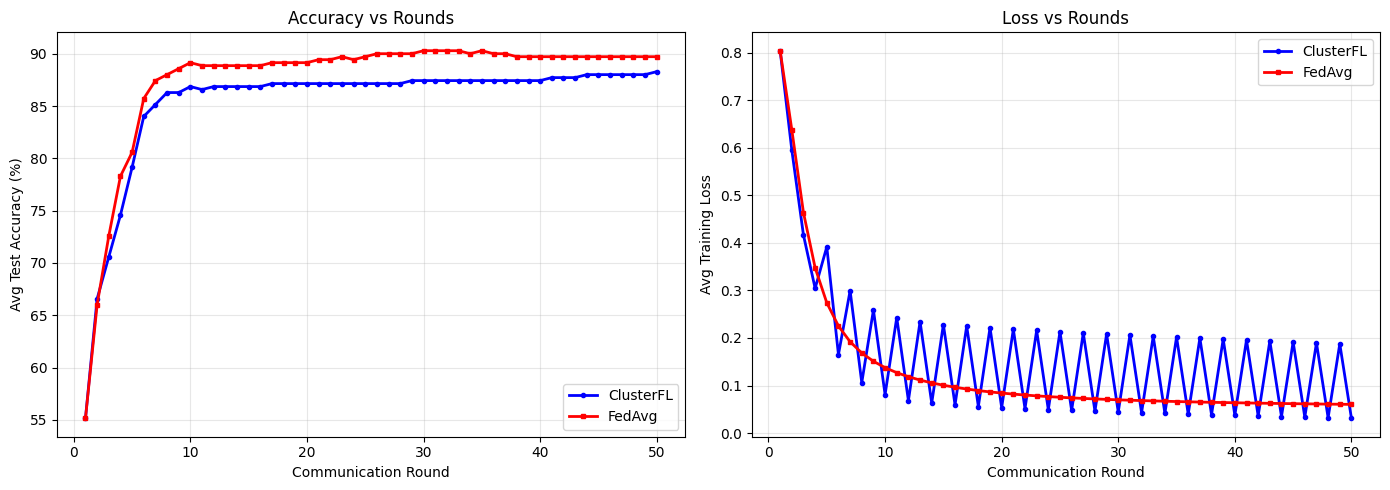

Saved: fig1_accuracy_loss_vs_rounds.png


In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

r_cfl = range(1, len(results['round_accuracies']) + 1)
r_fa = range(1, len(fedavg_results['round_accuracies']) + 1)

ax1.plot(r_cfl, [a*100 for a in results['round_accuracies']], 'b-o', ms=3, lw=2, label='ClusterFL')
ax1.plot(r_fa, [a*100 for a in fedavg_results['round_accuracies']], 'r-s', ms=3, lw=2, label='FedAvg')
ax1.set_xlabel('Communication Round'); ax1.set_ylabel('Avg Test Accuracy (%)')
ax1.set_title('Accuracy vs Rounds'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(r_cfl, results['round_losses'], 'b-o', ms=3, lw=2, label='ClusterFL')
ax2.plot(r_fa, fedavg_results['round_losses'], 'r-s', ms=3, lw=2, label='FedAvg')
ax2.set_xlabel('Communication Round'); ax2.set_ylabel('Avg Training Loss')
ax2.set_title('Loss vs Rounds'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_accuracy_loss_vs_rounds.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_accuracy_loss_vs_rounds.png")


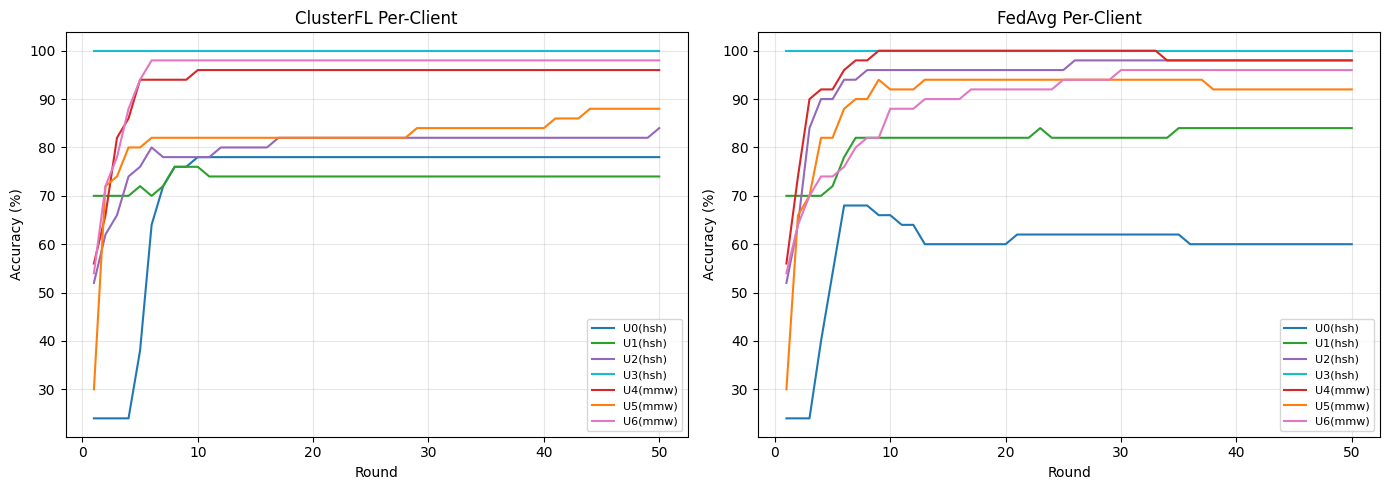

Saved: fig2_per_client_accuracy.png


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_c0 = ['#1f77b4', '#2ca02c', '#9467bd', '#17becf']
colors_c1 = ['#d62728', '#ff7f0e', '#e377c2']

for uid in range(NUM_OF_TOTAL_USERS):
    c = colors_c0[uid] if uid < 4 else colors_c1[uid-4]
    cn = "hsh" if uid < 4 else "mmw"
    r = range(1, len(results['per_user_accuracies'][uid]) + 1)
    ax1.plot(r, [a*100 for a in results['per_user_accuracies'][uid]], color=c, label=f'U{uid}({cn})', lw=1.5)
    r2 = range(1, len(fedavg_results['per_user_accuracies'][uid]) + 1)
    ax2.plot(r2, [a*100 for a in fedavg_results['per_user_accuracies'][uid]], color=c, label=f'U{uid}({cn})', lw=1.5)

ax1.set_xlabel('Round'); ax1.set_ylabel('Accuracy (%)'); ax1.set_title('ClusterFL Per-Client')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('Round'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('FedAvg Per-Client')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_per_client_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_per_client_accuracy.png")


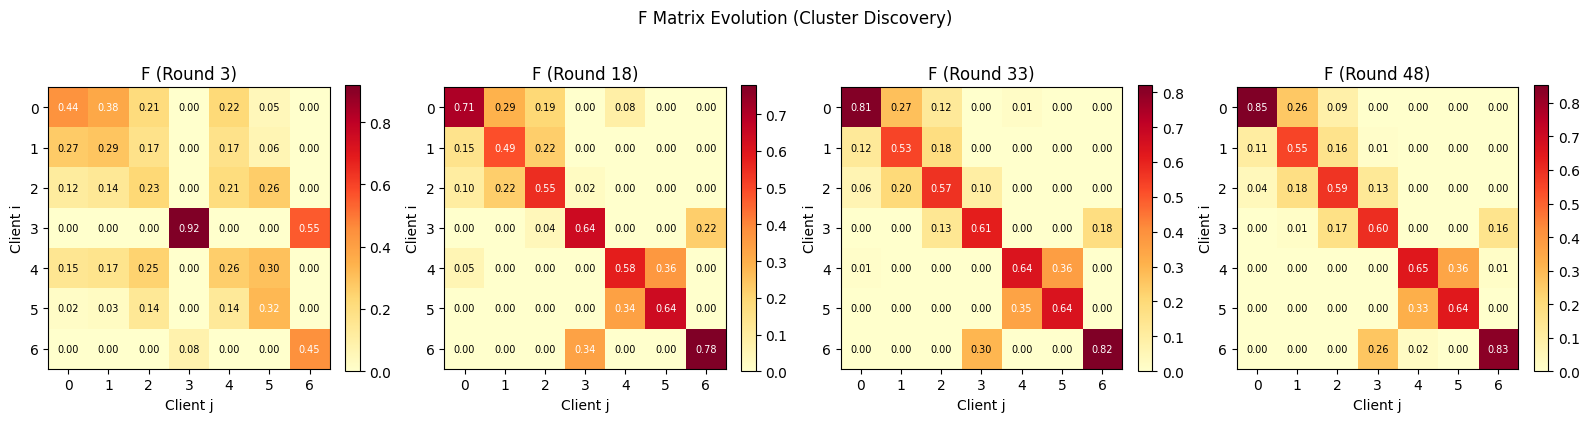

Saved: fig3_F_matrix.png
Expected: Block-diagonal with {0,1,2,3}=hsh and {4,5,6}=mmw clustered


In [42]:
n_snaps = min(len(results['F_matrices']), 4)
if n_snaps > 0:
    fig, axes = plt.subplots(1, n_snaps, figsize=(4*n_snaps, 4))
    if n_snaps == 1:
        axes = [axes]
    indices = np.linspace(0, len(results['F_matrices'])-1, n_snaps).astype(int)

    for idx, si in enumerate(indices):
        Fs = np.array(results['F_matrices'][si])
        rn = (si + 1) * inner_iteration
        im = axes[idx].imshow(Fs, cmap='YlOrRd', aspect='equal')
        axes[idx].set_title(f'F (Round {rn})')
        axes[idx].set_xlabel('Client j'); axes[idx].set_ylabel('Client i')
        axes[idx].set_xticks(range(NUM_OF_TOTAL_USERS))
        axes[idx].set_yticks(range(NUM_OF_TOTAL_USERS))
        for i in range(NUM_OF_TOTAL_USERS):
            for j in range(NUM_OF_TOTAL_USERS):
                axes[idx].text(j, i, f'{Fs[i,j]:.2f}', ha='center', va='center',
                              fontsize=7, color='white' if Fs[i,j] > 0.3 else 'black')
        plt.colorbar(im, ax=axes[idx], fraction=0.046)

    plt.suptitle('F Matrix Evolution (Cluster Discovery)', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'fig3_F_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig3_F_matrix.png")
    print("Expected: Block-diagonal with {0,1,2,3}=hsh and {4,5,6}=mmw clustered")
else:
    print("No F matrix snapshots available.")


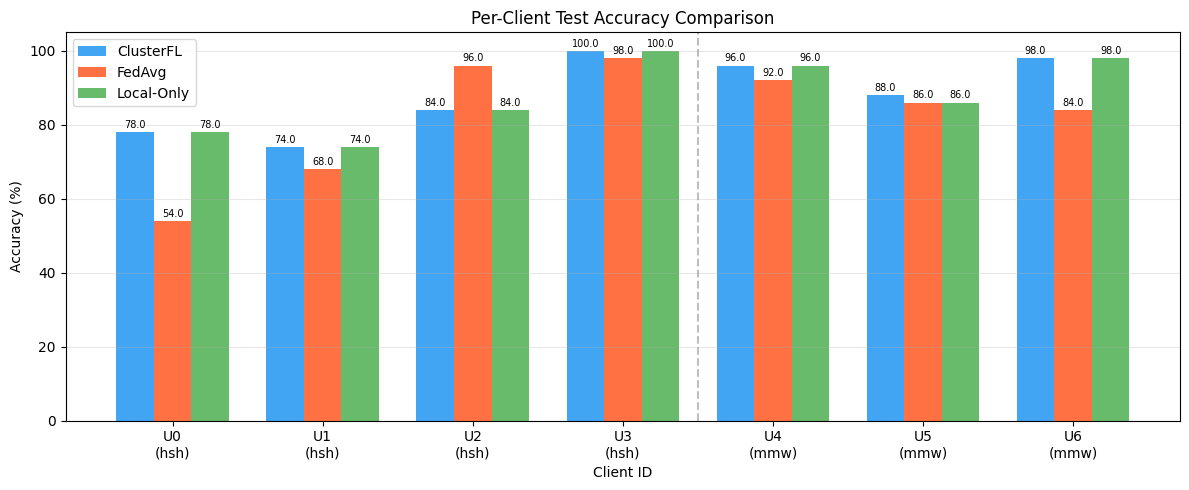

Saved: fig4_bar_chart.png


In [43]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(NUM_OF_TOTAL_USERS)
w = 0.25
cfl = [results['final_user_accuracies'][i]*100 for i in range(NUM_OF_TOTAL_USERS)]
fa = [fedavg_results['final_user_accuracies'][i]*100 for i in range(NUM_OF_TOTAL_USERS)]
lo = [local_only_results['final_user_accuracies'][i]*100 for i in range(NUM_OF_TOTAL_USERS)]

b1 = ax.bar(x-w, cfl, w, label='ClusterFL', color='#2196F3', alpha=0.85)
b2 = ax.bar(x, fa, w, label='FedAvg', color='#FF5722', alpha=0.85)
b3 = ax.bar(x+w, lo, w, label='Local-Only', color='#4CAF50', alpha=0.85)

ax.set_xlabel('Client ID'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Client Test Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels([f'U{i}\n({"hsh" if i<4 else "mmw"})' for i in range(NUM_OF_TOTAL_USERS)])
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}', xy=(bar.get_x()+bar.get_width()/2, h),
                   xytext=(0,3), textcoords="offset points", ha='center', fontsize=7)

ax.axvline(x=3.5, color='gray', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_bar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_bar_chart.png")


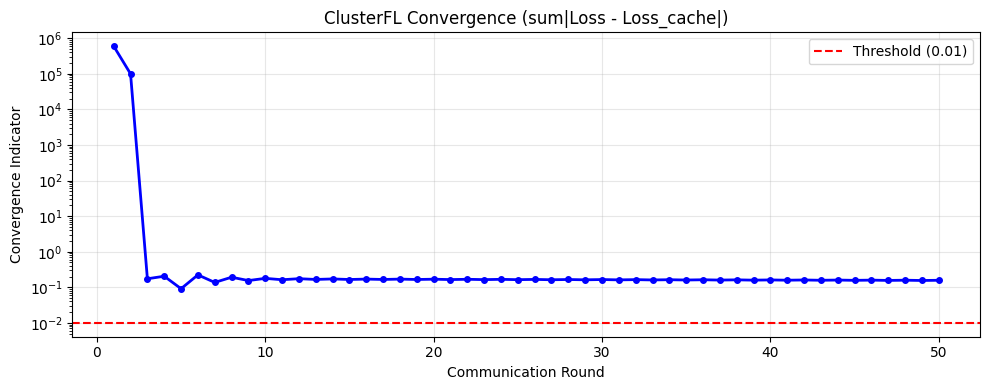

Saved: fig5_convergence.png


In [44]:
fig, ax = plt.subplots(figsize=(10, 4))
r = range(1, len(results['convergence']) + 1)
ax.plot(r, results['convergence'], 'b-o', ms=4, lw=2)
ax.axhline(y=convergence_threshold, color='r', ls='--', label=f'Threshold ({convergence_threshold})')
ax.set_xlabel('Communication Round'); ax.set_ylabel('Convergence Indicator')
ax.set_title('ClusterFL Convergence (sum|Loss - Loss_cache|)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_convergence.png")


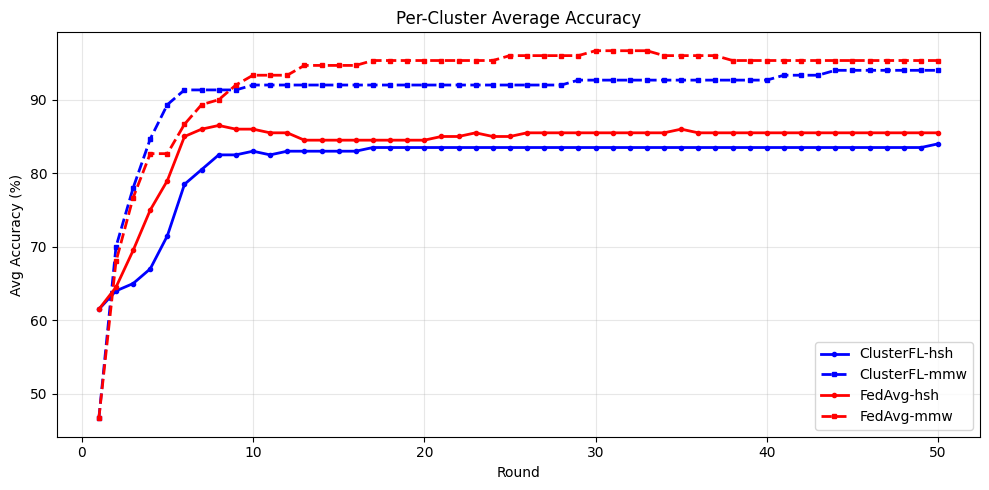

Saved: fig6_per_cluster.png


In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
nr = len(results['per_user_accuracies'][0])
c0_cfl_r = [np.mean([results['per_user_accuracies'][i][r] for i in range(4)])*100 for r in range(nr)]
c1_cfl_r = [np.mean([results['per_user_accuracies'][i][r] for i in range(4,7)])*100 for r in range(nr)]
c0_fa_r = [np.mean([fedavg_results['per_user_accuracies'][i][r] for i in range(4)])*100 for r in range(nr)]
c1_fa_r = [np.mean([fedavg_results['per_user_accuracies'][i][r] for i in range(4,7)])*100 for r in range(nr)]
rp = range(1, nr+1)

ax.plot(rp, c0_cfl_r, 'b-o', ms=3, lw=2, label='ClusterFL-hsh')
ax.plot(rp, c1_cfl_r, 'b-s', ms=3, lw=2, ls='--', label='ClusterFL-mmw')
ax.plot(rp, c0_fa_r, 'r-o', ms=3, lw=2, label='FedAvg-hsh')
ax.plot(rp, c1_fa_r, 'r-s', ms=3, lw=2, ls='--', label='FedAvg-mmw')

ax.set_xlabel('Round'); ax.set_ylabel('Avg Accuracy (%)')
ax.set_title('Per-Cluster Average Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig6_per_cluster.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_per_cluster.png")


In [46]:
print("SAVING ALL RESULTS")

with open(os.path.join(RESULTS_DIR, 'clusterfl_results.json'), 'w') as f:
    json.dump({
        'round_losses': results['round_losses'],
        'round_accuracies': results['round_accuracies'],
        'per_user_losses': dict(results['per_user_losses']),
        'per_user_accuracies': dict(results['per_user_accuracies']),
        'final_user_accuracies': results['final_user_accuracies'],
        'convergence': results['convergence'],
        'final_F_matrix': results['final_F_matrix'],
        'total_time_seconds': results['total_time_seconds'],
        'converged': results['converged'],
    }, f, indent=2)
print("  clusterfl_results.json")

with open(os.path.join(RESULTS_DIR, 'fedavg_results.json'), 'w') as f:
    json.dump({
        'round_losses': fedavg_results['round_losses'],
        'round_accuracies': fedavg_results['round_accuracies'],
        'per_user_losses': dict(fedavg_results['per_user_losses']),
        'per_user_accuracies': dict(fedavg_results['per_user_accuracies']),
        'final_user_accuracies': fedavg_results['final_user_accuracies'],
    }, f, indent=2)
print("  fedavg_results.json")

with open(os.path.join(RESULTS_DIR, 'local_only_results.json'), 'w') as f:
    json.dump(local_only_results, f, indent=2)
print("  local_only_results.json")

np.savetxt(os.path.join(RESULTS_DIR, 'final_F_matrix.txt'), F)
print("  final_F_matrix.txt")

np.save(os.path.join(RESULTS_DIR, 'final_W_matrix.npy'), W)
print("  final_W_matrix.npy")

config = {
    'dataset': DATASET_NAME, 'num_clients': NUM_OF_TOTAL_USERS,
    'num_classes': NUM_OF_CLASS, 'feature_dim': DIMENSION_OF_FEATURE,
    'batch_size': _BATCH_SIZE, 'local_epochs': local_iter,
    'comm_rounds': outer_iter, 'learning_rate': initial_learning_rate,
    'alpha': alpha, 'beta': beta, 'rho': rho,
    'inner_iteration': inner_iteration, 'softmax_temperature': softmax_temperature,
    'w_dim': W_DIM, 'seed': SEED, 'full_experiment': FULL_EXPERIMENT,
    'train_samples_per_user': train_N_set.tolist(),
}
with open(os.path.join(RESULTS_DIR, 'experiment_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print("  experiment_config.json")

comp_rows = []
for uid in range(NUM_OF_TOTAL_USERS):
    comp_rows.append({
        'user_id': uid, 'cluster': 'hsh' if uid < 4 else 'mmw',
        'clusterfl': results['final_user_accuracies'][uid],
        'fedavg': fedavg_results['final_user_accuracies'][uid],
        'local_only': local_only_results['final_user_accuracies'][uid],
    })
pd.DataFrame(comp_rows).to_csv(os.path.join(RESULTS_DIR, 'comparison.csv'), index=False)
print("  comparison.csv")

print(f"\nAll files in {RESULTS_DIR}:")
for f in sorted(os.listdir(RESULTS_DIR)):
    sz = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
    print(f"   {f} ({sz:.1f} KB)")


SAVING ALL RESULTS
  clusterfl_results.json
  fedavg_results.json
  local_only_results.json
  final_F_matrix.txt
  final_W_matrix.npy
  experiment_config.json
  comparison.csv

All files in /content/results:
   clusterfl_results.json (18.3 KB)
   comparison.csv (0.2 KB)
   experiment_config.json (0.4 KB)
   fedavg_results.json (16.0 KB)
   fig1_accuracy_loss_vs_rounds.png (114.1 KB)
   fig2_per_client_accuracy.png (98.1 KB)
   fig3_F_matrix.png (133.1 KB)
   fig4_bar_chart.png (52.2 KB)
   fig5_convergence.png (51.0 KB)
   fig6_per_cluster.png (65.4 KB)
   final_F_matrix.txt (1.2 KB)
   final_W_matrix.npy (14831.5 KB)
   local_only_results.json (0.1 KB)


In [47]:
print("=" * 60)
print("REPRODUCIBILITY SUMMARY")
print("=" * 60)
print(f"""
Dataset:             {DATASET_NAME}
Clients:             {NUM_OF_TOTAL_USERS}
Clusters:            2 (ground truth)
Rounds:              {outer_iter} (ran {len(results['round_losses'])})
Local epochs:        {local_iter}
Batch size:          {_BATCH_SIZE}
LR:                  {initial_learning_rate}
Optimizer:           SGD
alpha/beta/rho:      {alpha}/{beta}/{rho}
F update freq:       {inner_iteration}
Softmax temp:        {softmax_temperature}
Model:               2-layer FC (900->300->3), {W_DIM:,} params
Seed:                {SEED}
Device:              {'GPU' if tf.test.is_gpu_available() else 'CPU'}

TensorFlow:          {tf.__version__}
NumPy:               {np.__version__}
Python:              {sys.version.split()[0]}

RESULTS:
  ClusterFL avg:     {np.mean(list(results['final_user_accuracies'].values()))*100:.2f}%
  FedAvg avg:        {np.mean(list(fedavg_results['final_user_accuracies'].values()))*100:.2f}%
  Local-Only avg:    {np.mean(list(local_only_results['final_user_accuracies'].values()))*100:.2f}%
  Converged:         {results['converged']}
  Time:              {results['total_time_seconds']:.1f}s
""")


REPRODUCIBILITY SUMMARY

Dataset:             imu_data_7
Clients:             7
Clusters:            2 (ground truth)
Rounds:              50 (ran 50)
Local epochs:        20
Batch size:          5
LR:                  0.01
Optimizer:           SGD
alpha/beta/rho:      0.001/0.0005/0.002
F update freq:       3
Softmax temp:        6.0
Model:               2-layer FC (900->300->3), 271,203 params
Seed:                0
Device:              GPU

TensorFlow:          2.20.0
NumPy:               2.1.3
Python:              3.13.15

RESULTS:
  ClusterFL avg:     88.29%
  FedAvg avg:        82.57%
  Local-Only avg:    88.00%
  Converged:         False
  Time:              388.5s

